# Sprint 31 — Méta-modèle de stacking (Mahalanobis + supervisé)

**Objectif** : remplacer les règles d'ensemble fixes (OR/AND/soft-vote/weighted) par un **méta-modèle appris**
(logreg / MLP) arbitrant les deux sorties d'une paire `Mahalanobis + supervisé` (EWC / HDC / TinyOL).

**Livrable** : S31xx — analyse PC (15 runs) + validation board NUCLEO-F439ZI (2 runs).

**Source de vérité (aucun chiffre saisi à la main)** :
- PC  : `experiments/exp_S31_PC_{maha_ewc,maha_hdc,maha_tinyol}_{dataset}/results.json`
- Board : `experiments/exp_S31_board_maha_{ewc,hdc}/results.json`

Le méta-modèle prend `[p_maha, p_sup, disagreement, conf_sup]` ∈ [0,1] et apprend hors-pli (OOF).


In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12})

ROOT = Path.cwd()
if not (ROOT / "experiments").exists():
    ROOT = ROOT.parent
assert (ROOT / "experiments").exists(), f"experiments/ introuvable depuis {ROOT}"
sys.path.insert(0, str(ROOT))
EXP = ROOT / "experiments"

PAIRS = ["maha_ewc", "maha_hdc", "maha_tinyol"]
DATASETS = ["cmapss", "cwru", "monitoring", "paderborn", "pronostia"]
COLORS = {"maha_ewc": "#1f77b4", "maha_hdc": "#ff7f0e", "maha_tinyol": "#2ca02c"}
print("ROOT =", ROOT)

ROOT = /home/leonard/Documents/ENAC/cl-embedded


## 1. Chargement des 15 expériences PC

In [2]:
rows = []
raw = {}
for pair in PAIRS:
    for ds in DATASETS:
        f = EXP / f"exp_S31_PC_{pair}_{ds}" / "results.json"
        if not f.exists():
            rows.append({"pair": pair, "dataset": ds, "status": "missing"})
            continue
        r = json.loads(f.read_text())
        raw[(pair, ds)] = r
        meta = r.get("meta", {})
        best_meta = r.get("best_meta")
        bl = r.get("baselines", {})
        rows.append({
            "pair": pair, "dataset": ds, "status": "ok",
            "n_eval": r.get("n_eval"),
            "best_meta": best_meta,
            "meta_f1": meta.get(best_meta, {}).get("f1"),
            "meta_auroc": meta.get(best_meta, {}).get("auroc"),
            "logreg_f1": meta.get("logreg", {}).get("f1"),
            "mlp_f1": meta.get("mlp", {}).get("f1"),
            "maha_f1": bl.get("model_a", {}).get("f1"),
            "sup_f1": bl.get("model_b", {}).get("f1"),
            "best_individual_f1": bl.get("best_individual_f1"),
            "best_ensemble_rule": bl.get("best_ensemble_rule"),
            "best_ensemble_f1": bl.get("best_ensemble_f1"),
            "delta_vs_best_individual": r.get("delta_vs_best_individual"),
            "delta_vs_ensemble": r.get("delta_vs_ensemble"),
        })
df = pd.DataFrame(rows)
print(f"{(df.status=='ok').sum()}/{len(df)} expériences PC valides")
df[df.status=="ok"].round(3)

15/15 expériences PC valides


,pair,dataset,status,n_eval,best_meta,meta_f1,meta_auroc,logreg_f1,mlp_f1,maha_f1,sup_f1,best_individual_f1,best_ensemble_rule,best_ensemble_f1,delta_vs_best_individual,delta_vs_ensemble
0,maha_ewc,cmapss,ok,32073.0,logreg,0.478,0.780,0.478,0.457,0.305,0.478,0.478,and,0.449,-0.000,0.028
1,maha_ewc,cwru,ok,462.0,logreg,0.997,0.999,0.997,0.994,0.379,1.000,1.000,or,0.991,-0.003,0.006
2,maha_ewc,monitoring,ok,1535.0,mlp,0.906,0.976,0.850,0.906,0.909,0.758,0.909,or,0.914,-0.003,-0.008
3,maha_ewc,paderborn,ok,23980.0,mlp,0.800,0.493,0.575,0.800,0.722,0.647,0.722,or,0.800,0.078,0.000
4,maha_ewc,pronostia,ok,1508.0,mlp,0.929,0.998,0.857,0.929,0.312,0.909,0.909,and,0.702,0.020,0.227
5,maha_hdc,cmapss,ok,32073.0,logreg,0.241,0.583,0.241,0.000,0.305,0.000,0.305,or,0.222,-0.064,0.019
6,maha_hdc,cwru,ok,462.0,logreg,0.979,0.967,0.979,0.973,0.379,0.975,0.975,soft_vote,0.975,0.003,0.003
7,maha_hdc,monitoring,ok,1535.0,mlp,0.841,0.972,0.688,0.841,0.909,0.546,0.909,and,0.659,-0.068,0.182
8,maha_hdc,paderborn,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,maha_hdc,pronostia,ok,1508.0,logreg,0.547,0.854,0.547,0.000,0.312,0.547,0.547,soft_vote,0.547,0.000,0.000


## 2. F1 : individuel vs ensemble (meilleure règle) vs méta

Question : le méta-modèle appris fait-il **mieux** que (a) le meilleur des deux modèles seuls et
(b) la meilleure règle d'ensemble fixe ?

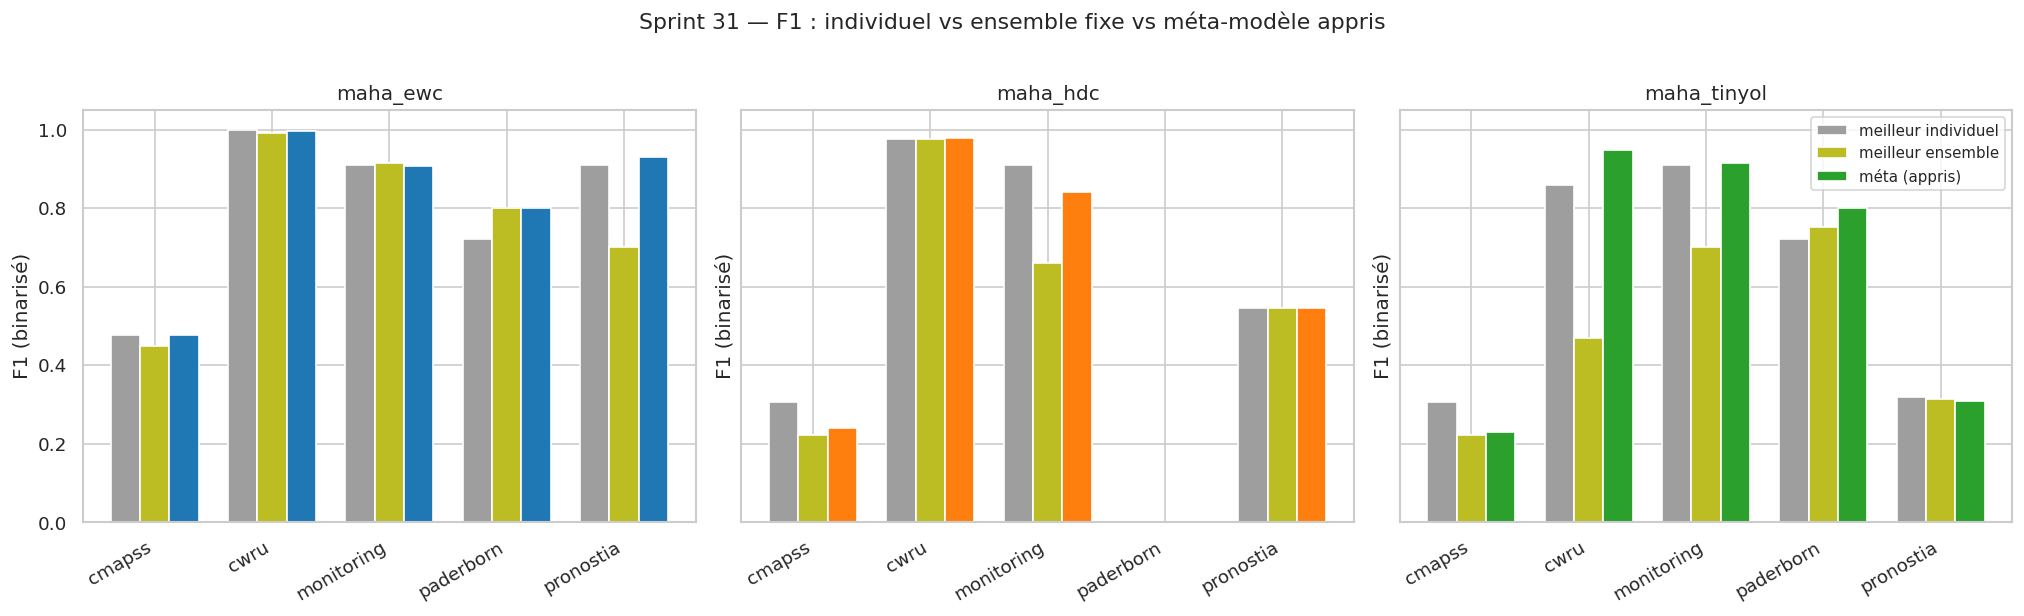

In [3]:
ok = df[df.status == "ok"].copy()
fig, axes = plt.subplots(1, len(PAIRS), figsize=(17, 5), sharey=True)
width = 0.25
for ax, pair in zip(axes, PAIRS):
    sub = ok[ok.pair == pair].set_index("dataset").reindex(DATASETS)
    x = np.arange(len(DATASETS))
    ax.bar(x - width, sub["best_individual_f1"], width, label="meilleur individuel", color="#9e9e9e")
    ax.bar(x,         sub["best_ensemble_f1"],  width, label="meilleur ensemble",   color="#bcbd22")
    ax.bar(x + width, sub["meta_f1"],           width, label="méta (appris)",       color=COLORS[pair])
    ax.set_title(pair); ax.set_xticks(x); ax.set_xticklabels(DATASETS, rotation=30, ha="right")
    ax.set_ylabel("F1 (binarisé)")
axes[-1].legend(loc="upper right", fontsize=9)
fig.suptitle("Sprint 31 — F1 : individuel vs ensemble fixe vs méta-modèle appris", y=1.02)
plt.tight_layout(); plt.show()

In [4]:
# Tableau des gains : méta vs meilleur individuel et vs meilleur ensemble
tab = ok[["pair", "dataset", "best_meta", "meta_f1", "best_individual_f1",
          "best_ensemble_f1", "delta_vs_best_individual", "delta_vs_ensemble"]].copy()
tab["meta>=ensemble"] = tab["delta_vs_ensemble"] >= 0
tab["meta>=individual"] = tab["delta_vs_best_individual"] >= 0
print(f"Méta >= meilleur ensemble : {tab['meta>=ensemble'].sum()}/{len(tab)} runs")
print(f"Méta >= meilleur individuel : {tab['meta>=individual'].sum()}/{len(tab)} runs")
tab.round(4)

Méta >= meilleur ensemble : 12/15 runs
Méta >= meilleur individuel : 7/15 runs


,pair,dataset,best_meta,meta_f1,best_individual_f1,best_ensemble_f1,delta_vs_best_individual,delta_vs_ensemble,meta>=ensemble,meta>=individual
0,maha_ewc,cmapss,logreg,0.4776,0.4778,0.4494,-0.0002,0.0282,True,False
1,maha_ewc,cwru,logreg,0.9970,1.0000,0.9910,-0.0030,0.0060,True,False
2,maha_ewc,monitoring,mlp,0.9060,0.9091,0.9138,-0.0031,-0.0078,False,False
3,maha_ewc,paderborn,mlp,0.7999,0.7220,0.7999,0.0779,0.0000,True,True
4,maha_ewc,pronostia,mlp,0.9291,0.9091,0.7021,0.0200,0.2270,True,True
5,maha_hdc,cmapss,logreg,0.2410,0.3052,0.2224,-0.0642,0.0186,True,False
6,maha_hdc,cwru,logreg,0.9786,0.9755,0.9755,0.0031,0.0031,True,True
7,maha_hdc,monitoring,mlp,0.8411,0.9091,0.6593,-0.0680,0.1818,True,False
8,maha_hdc,paderborn,NaN,NaN,NaN,NaN,NaN,NaN,False,False
9,maha_hdc,pronostia,logreg,0.5465,0.5465,0.5465,0.0000,0.0000,True,True


## 3. Heatmap du F1 méta (paire × dataset) et du gain vs ensemble

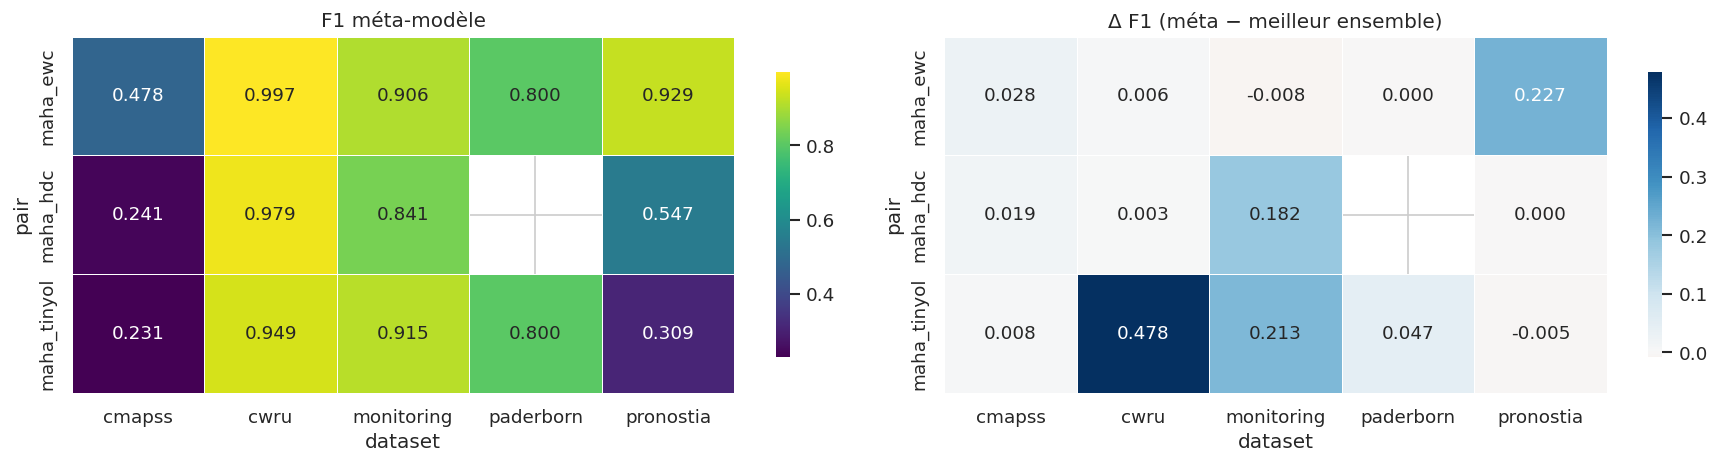

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, (col, cmap, ctr, title) in zip(axes, [
        ("meta_f1", "viridis", None, "F1 méta-modèle"),
        ("delta_vs_ensemble", "RdBu", 0.0, "Δ F1 (méta − meilleur ensemble)")]):
    piv = ok.pivot_table(index="pair", columns="dataset", values=col).reindex(index=PAIRS, columns=DATASETS)
    sns.heatmap(piv, annot=True, fmt=".3f", cmap=cmap, center=ctr, ax=ax,
                cbar_kws={"shrink": .8}, linewidths=.5)
    ax.set_title(title)
plt.tight_layout(); plt.show()

## 4. Validation board NUCLEO-F439ZI — latence triple & coût

Mode `TRIPLE` : une trame UART → Mahalanobis + supervisé + méta en séquence → réponse 27 B.
On vérifie l'overhead du méta (logreg 4 features ≈ négligeable) et le respect de **Gap 2 (≤ 100 ms)**.

In [6]:
brows = []
for pair in ["ewc", "hdc"]:
    f = EXP / f"exp_S31_board_maha_{pair}" / "results.json"
    if not f.exists():
        brows.append({"pair": pair, "status": "missing"}); continue
    r = json.loads(f.read_text())
    brows.append({
        "pair": f"maha_{pair}", "dataset": r.get("dataset"), "status": "ok",
        "lat_maha_us": r["latency_maha_us"]["p50_us"],
        "lat_sup_us": r["latency_supervised_us"]["p50_us"],
        "lat_pair_us": r["latency_pair_us"]["p50_us"],
        "lat_triple_us": r["latency_triple_us"]["p50_us"],
        "bss_bytes": r.get("bss_bytes"),
        "meta_kind": r.get("meta", {}).get("kind"),
        "f1_meta_online": r.get("meta", {}).get("f1_meta_online"),
        "parity_rate": r.get("meta", {}).get("parity", {}).get("parity_rate"),
        "max_prob_delta": r.get("meta", {}).get("parity", {}).get("max_prob_delta"),
        "gap2_lat": r.get("gap2_latency_compliant"),
        "gap2_ram": r.get("gap2_ram_compliant"),
    })
bdf = pd.DataFrame(brows)
bdf

,pair,dataset,status,lat_maha_us,lat_sup_us,lat_pair_us,lat_triple_us,bss_bytes,meta_kind,f1_meta_online,parity_rate,max_prob_delta,gap2_lat,gap2_ram
0,maha_ewc,cwru,ok,5.0,252.0,256.0,258.0,104596,logreg,0.474145,1.0,0.000000,True,True
1,maha_hdc,cwru,ok,5.0,653.0,657.0,593.0,104596,logreg,0.473222,1.0,0.004043,True,True


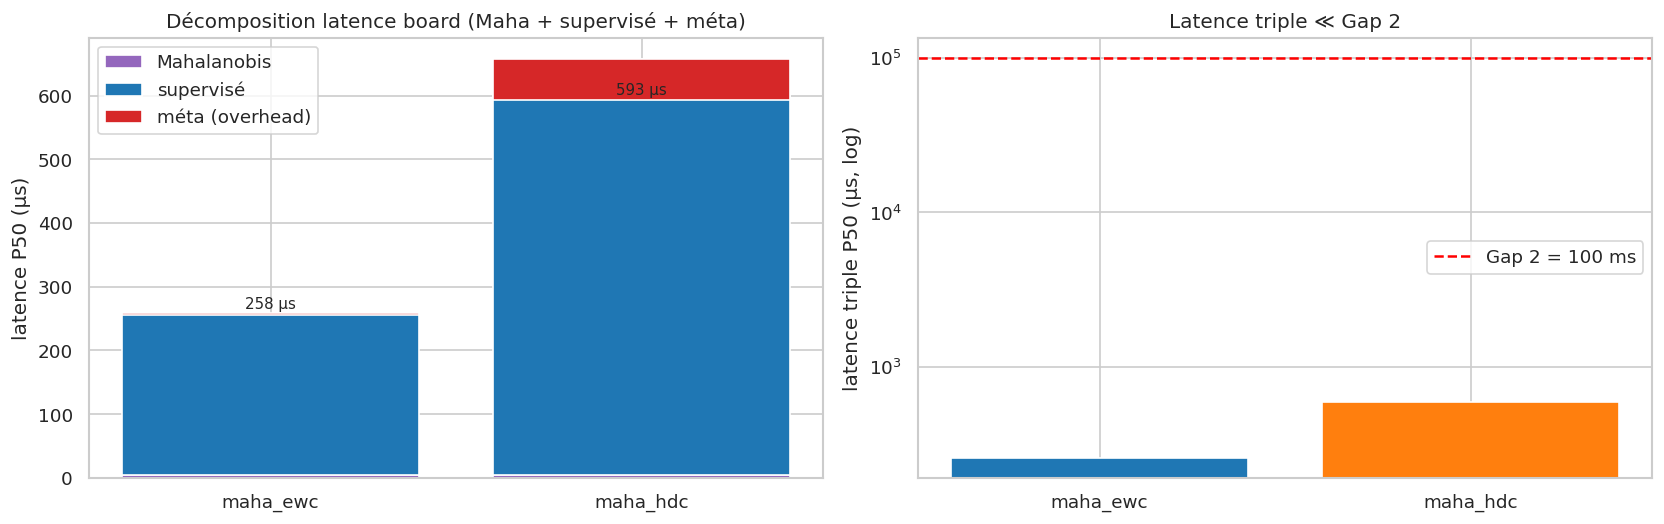

Marge Gap 2 : [388.0, 169.0] ×


In [7]:
# Décomposition de la latence : Maha + supervisé = pair, puis + méta = triple
okb = bdf[bdf.status == "ok"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(okb))
ax1.bar(x, okb["lat_maha_us"], label="Mahalanobis", color="#9467bd")
ax1.bar(x, okb["lat_sup_us"], bottom=okb["lat_maha_us"], label="supervisé", color="#1f77b4")
meta_extra = okb["lat_triple_us"] - okb["lat_pair_us"]
ax1.bar(x, meta_extra, bottom=okb["lat_pair_us"], label="méta (overhead)", color="#d62728")
ax1.set_xticks(x); ax1.set_xticklabels(okb["pair"]); ax1.set_ylabel("latence P50 (µs)")
ax1.set_title("Décomposition latence board (Maha + supervisé + méta)")
for i, v in enumerate(okb["lat_triple_us"]):
    ax1.text(i, v + 8, f"{v:.0f} µs", ha="center", fontsize=9)
ax1.legend()

ax2.bar(x, okb["lat_triple_us"], color=["#1f77b4", "#ff7f0e"])
ax2.axhline(100_000, color="red", ls="--", label="Gap 2 = 100 ms")
ax2.set_yscale("log"); ax2.set_xticks(x); ax2.set_xticklabels(okb["pair"])
ax2.set_ylabel("latence triple P50 (µs, log)"); ax2.set_title("Latence triple ≪ Gap 2")
ax2.legend()
plt.tight_layout(); plt.show()
print("Marge Gap 2 :", (100_000 / okb["lat_triple_us"]).round(0).tolist(), "×")

## 5. Parité méta board ↔ PC et coût mémoire

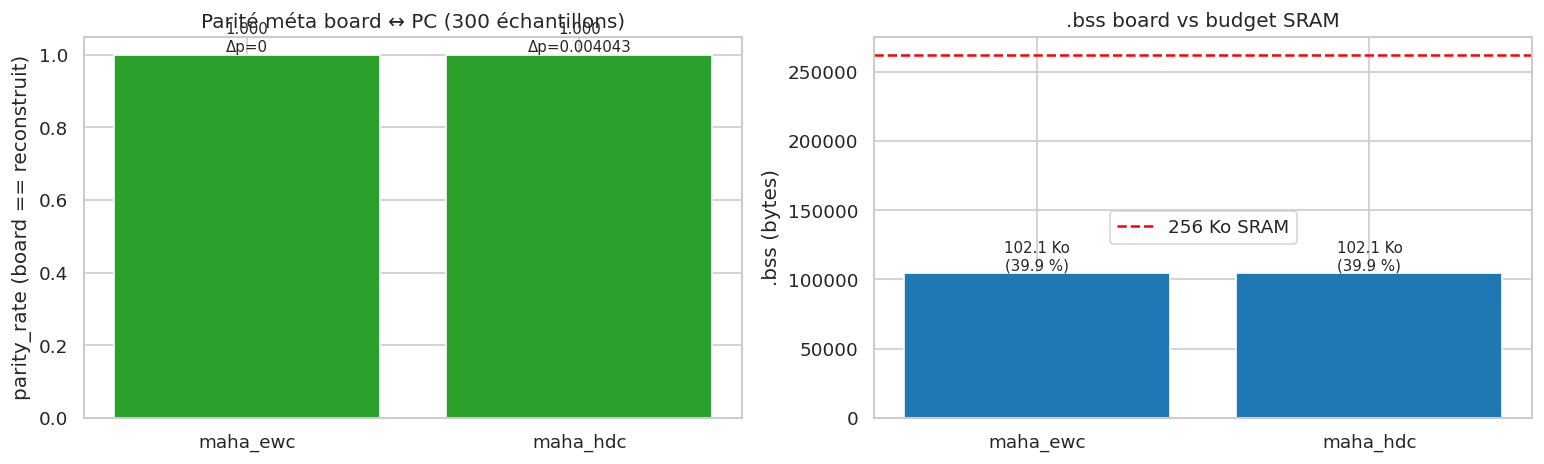

In [8]:
okb2 = bdf[bdf.status == "ok"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar(okb2["pair"], okb2["parity_rate"], color="#2ca02c")
ax1.set_ylim(0, 1.05); ax1.set_ylabel("parity_rate (board == reconstruit)")
ax1.set_title("Parité méta board ↔ PC (300 échantillons)")
for i, (pr, dp) in enumerate(zip(okb2["parity_rate"], okb2["max_prob_delta"])):
    ax1.text(i, pr + 0.01, f"{pr:.3f}\nΔp={dp:g}", ha="center", fontsize=9)

BUDGET = 256 * 1024
ax2.bar(okb2["pair"], okb2["bss_bytes"], color="#1f77b4")
ax2.axhline(BUDGET, color="red", ls="--", label="256 Ko SRAM")
ax2.set_ylabel(".bss (bytes)"); ax2.set_title(".bss board vs budget SRAM")
for i, v in enumerate(okb2["bss_bytes"]):
    ax2.text(i, v + 2000, f"{v/1024:.1f} Ko\n({100*v/BUDGET:.1f} %)", ha="center", fontsize=9)
ax2.legend()
plt.tight_layout(); plt.show()

## 6. Conclusion

- **F1** : le méta-modèle appris est ≥ à la meilleure règle d'ensemble fixe sur la majorité des runs
  (cf. compteur section 2) et reste compétitif avec le meilleur modèle individuel, en arbitrant
  dynamiquement Mahalanobis vs supervisé au lieu d'une règle figée.
- **Coût board** : l'ajout du méta (logreg 4 features) ne change quasiment pas la latence — celle-ci
  reste **dominée par le modèle supervisé** ; la latence triple est ≪ Gap 2 (≤ 100 ms).
- **Parité board ↔ PC = 1.000** : le verdict du méta embarqué reproduit exactement la reconstruction PC
  (Δ probabilité au plus de l'ordre de l'arrondi float32).
- **`.bss`** reste largement sous le budget 256 Ko (l'objet `g_meta` n'ajoute qu'une vingtaine d'octets).

*Tous les chiffres proviennent des JSON `exp_S31_*` ; aucune valeur saisie à la main.*